In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from pathlib import Path
from datetime import datetime
from scipy.stats import lognorm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


from src.pipeline.calculate_evs import *
from src.utils.helper_functions import *
from src.features.ngboost_points import *
from src.features.feature_engine import FeatureEngine
from src.utils.team_info import teamStarPlayer, projectedStartingFive, mainStartingFive
from src.models.ngboost_model import predict_mean
from src.pipeline.pipeline_pts import build_ngboost_points_features

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)
today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')

def get_latest_file(pattern):
    files = list(Path('data/raw/player_lines').glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

us_file = get_latest_file(f'NBA_US_{today}*.csv')
dfs_file = get_latest_file(f'NBA_DFS_{today}*.csv')

if us_file is None:
    raise FileNotFoundError(f"No NBA_US file found for {today}")
if dfs_file is None:
    raise FileNotFoundError(f"No NBA_DFS file found for {today}")

s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
usData = pd.read_csv(us_file)
dfsData = pd.read_csv(dfs_file)

print(f"Loaded: {us_file.name}")
print(f"Loaded: {dfs_file.name}")
dfsData.head()

Loaded: NBA_US_20251211_155933.csv
Loaded: NBA_DFS_20251211_155826.csv


,BOOKMAKER,CATEGORY,NAME,OVER/UNDER,LINE,ODDS,COMMENCE_TIME,LAST_UPDATE,DATA_PULLED_AT
0,Underdog,player_points,Anfernee Simons,Over,11.5,-137,2025-12-12,2025-12-11T23:57:54Z,2025-12-11 15:58:26
1,Underdog,player_points,Anfernee Simons,Under,11.5,-137,2025-12-12,2025-12-11T23:57:54Z,2025-12-11 15:58:26
2,Underdog,player_points,Jaylen Brown,Over,29.5,-137,2025-12-12,2025-12-11T23:57:54Z,2025-12-11 15:58:26
3,Underdog,player_points,Jaylen Brown,Under,29.5,-137,2025-12-12,2025-12-11T23:57:54Z,2025-12-11 15:58:26
4,Underdog,player_points,Myles Turner,Over,12.5,-137,2025-12-12,2025-12-11T23:57:54Z,2025-12-11 15:58:26


In [3]:
# dfsData = pd.read_csv('data/raw/player_lines/NBA_DFS_20251206_134221.csv')
# usData = pd.read_csv('data/raw/player_lines/NBA_US_20251206_134342.csv')
# s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')

In [4]:
name = 'Jaylen Brown'
betting_line = 29.5 
odds = -137

engine = FeatureEngine({
    "min_model": "src/models/saved/min_model.pkl",
    "usg_model": "src/models/saved/usg_model.pkl",
    "fga_model": "src/models/saved/fga_model.pkl",
    "ngboost_model_wrapper": "src/models/saved/pts_model_wrapper.pkl"
})

# Get prediction
result = engine.project_player(
    player_name=name,
    data=s26,
    date="2025-12-07",
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)

print("Prediction Result:")
print(f"  Predicted Minutes: {result['predicted_minutes']:.2f}")
print(f"  Predicted Usage: {result['predicted_usage']:.3f}")
print(f"  Predicted FGA: {result['predicted_fga']:.2f}")
print(f"  Predicted Points: {result['predicted_points']:.2f}")

Prediction Result:
  Predicted Minutes: 29.86
  Predicted Usage: 0.313
  Predicted FGA: 17.06
  Predicted Points: 29.50


In [5]:
# Create log-normal distribution using calibrations
if engine.ngboost_model_wrapper:
    # Get the model and features
    mean_model = engine.ngboost_model_wrapper['mean_model']
    features_list = engine.ngboost_model_wrapper['features']
    variance_calibration = engine.ngboost_model_wrapper.get('variance_calibration')
    bins = engine.ngboost_model_wrapper.get('bins')
    
    median_pred = result['predicted_points']
    
    feature_dict = build_ngboost_points_features(
        player_name=name,
        data=s26,
        current_date="2025-12-06",
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp,
        predicted_minutes=result['predicted_minutes'],
        predicted_usage=result['predicted_usage']
    )
    
    if feature_dict:
        feature_vector = [feature_dict.get(f, 0.0) for f in features_list]
        feature_df = pd.DataFrame([feature_vector], columns=features_list)
        feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
        
        # Get distribution parameters
        dist = mean_model.pred_dist(feature_df[features_list].fillna(feature_df[features_list].median()))
        mean_log = float(dist.loc[0])
        scale_log = float(dist.scale[0])
        var_log = scale_log ** 2
        
        # Apply calibrations based on bins
        if variance_calibration and bins:
            low_bin, medium_bin, high_bin = bins[0], bins[1], bins[2]
            if (median_pred >= low_bin[0]) and (median_pred < low_bin[1]):
                var_log *= variance_calibration.get('low', 1.0)
                print(f"\nUsing LOW bin calibration: {variance_calibration.get('low')}")
            elif (median_pred >= medium_bin[0]) and (median_pred < medium_bin[1]):
                var_log *= variance_calibration.get('medium', 1.0)
                print(f"\nUsing MEDIUM bin calibration: {variance_calibration.get('medium')}")
            elif (median_pred >= high_bin[0]) and (median_pred < high_bin[1]):
                var_log *= variance_calibration.get('high', 1.0)
                print(f"\nUsing HIGH bin calibration: {variance_calibration.get('high')}")
        
        std_log = np.sqrt(var_log)
        distribution = lognorm(s=std_log, scale=np.exp(mean_log))
        
        print(f"\nLog-Normal Distribution Parameters:")
        print(f"  Mean (log space): {mean_log:.4f}")
        print(f"  Std (log space): {std_log:.4f}")
        print(f"  Median: {median_pred:.2f}")
        print(f"  Mean: {distribution.mean():.2f}")
        print(f"  Std: {distribution.std():.2f}")
        
        samples = distribution.rvs(size=10000)
        print(f"\nDistribution Statistics (from samples):")
        print(f"  5th percentile: {np.percentile(samples, 5):.2f}")
        print(f"  25th percentile: {np.percentile(samples, 25):.2f}")
        print(f"  50th percentile (median): {np.percentile(samples, 50):.2f}")
        print(f"  75th percentile: {np.percentile(samples, 75):.2f}")
        print(f"  95th percentile: {np.percentile(samples, 95):.2f}")
        
        # Monte Carlo Simulation
        print("\n" + "="*60)
        print("MONTE CARLO SIMULATION")
        print("="*60)
        
        # Create test lines in 0.5 intervals around betting line
        betting_line_rounded = round(betting_line * 2) / 2
        num_lines_below = 2  # 4 * 0.5 = 2.0 points below
        num_lines_above = 2  # 4 * 0.5 = 2.0 points above
        
        test_lines = []
        for i in range(-num_lines_below, num_lines_above + 1):
            test_line = betting_line_rounded + (i * 0.5)
            if test_line > 0:
                test_lines.append(test_line)
        
        # Ensure actual betting line is included
        if betting_line not in test_lines:
            test_lines.append(betting_line)
        
        test_lines = sorted(set(test_lines))
        
        # Convert odds to decimal
        if odds > 0:
            dec_odds = 1 + (odds / 100.0)
        else:
            dec_odds = 1 + (100.0 / abs(odds))
        
        print(f"\nTesting {len(samples):,} simulations against different lines:")
        print(f"Predicted Median: {median_pred:.2f} points")
        print(f"Betting Line: {betting_line:.1f} points | Odds: {odds:+d} ({dec_odds:.3f} decimal)")
        print(f"Test Lines: {[f'{l:.1f}' for l in test_lines]}\n")
        
        results = []
        for test_line in test_lines:
            # Calculate probabilities - these should sum to 100%
            prob_over = 1 - distribution.cdf(test_line)
            prob_under = distribution.cdf(test_line)
            
            # Monte Carlo: count wins (for validation)
            over_wins = np.sum(samples > test_line)
            under_wins = np.sum(samples <= test_line)
            over_rate = over_wins / len(samples)
            under_rate = under_wins / len(samples)
            
            # Calculate expected value using actual odds
            ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
            ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)
            
            results.append({
                'Line': test_line,
                'Prob_Over': prob_over,
                'Prob_Under': prob_under,
                'MC_Over_Rate': over_rate,
                'MC_Under_Rate': under_rate,
                'EV_Over': ev_over,
                'EV_Under': ev_under
            })
            
            # Determine best bet
            if ev_over > ev_under and ev_over > 0:
                best_bet = f"OVER {test_line:.1f} (EV: {ev_over:+.3f})"
            elif ev_under > ev_over and ev_under > 0:
                best_bet = f"UNDER {test_line:.1f} (EV: {ev_under:+.3f})"
            else:
                best_bet = "No positive EV"
            
            # Highlight the actual betting line
            line_marker = " <-- BETTING LINE" if abs(test_line - betting_line) < 0.01 else ""
            print(f"Line: {test_line:.1f}{line_marker}")
            print(f"  Over: {prob_over:.1%} (MC: {over_rate:.1%}) | EV: {ev_over:+.3f}")
            print(f"  Under: {prob_under:.1%} (MC: {under_rate:.1%}) | EV: {ev_under:+.3f}")
            print(f"  Sum: {(prob_over + prob_under):.1%}")  # Should be 100%
            print(f"  → {best_bet}\n")


Using HIGH bin calibration: 0.95

Log-Normal Distribution Parameters:
  Mean (log space): 3.4176
  Std (log space): 0.2817
  Median: 29.50
  Mean: 31.73
  Std: 9.12

Distribution Statistics (from samples):
  5th percentile: 19.37
  25th percentile: 25.35
  50th percentile (median): 30.60
  75th percentile: 37.12
  95th percentile: 48.34

MONTE CARLO SIMULATION

Testing 10,000 simulations against different lines:
Predicted Median: 29.50 points
Betting Line: 29.5 points | Odds: -137 (1.730 decimal)
Test Lines: ['28.5', '29.0', '29.5', '30.0', '30.5']

Line: 28.5
  Over: 59.5% (MC: 60.4%) | EV: +0.029
  Under: 40.5% (MC: 39.6%) | EV: -0.299
  Sum: 100.0%
  → OVER 28.5 (EV: +0.029)

Line: 29.0
  Over: 57.1% (MC: 57.9%) | EV: -0.012
  Under: 42.9% (MC: 42.1%) | EV: -0.258
  Sum: 100.0%
  → No positive EV

Line: 29.5 <-- BETTING LINE
  Over: 54.7% (MC: 55.4%) | EV: -0.054
  Under: 45.3% (MC: 44.6%) | EV: -0.216
  Sum: 100.0%
  → No positive EV

Line: 30.0
  Over: 52.3% (MC: 53.1%) | EV: -0.

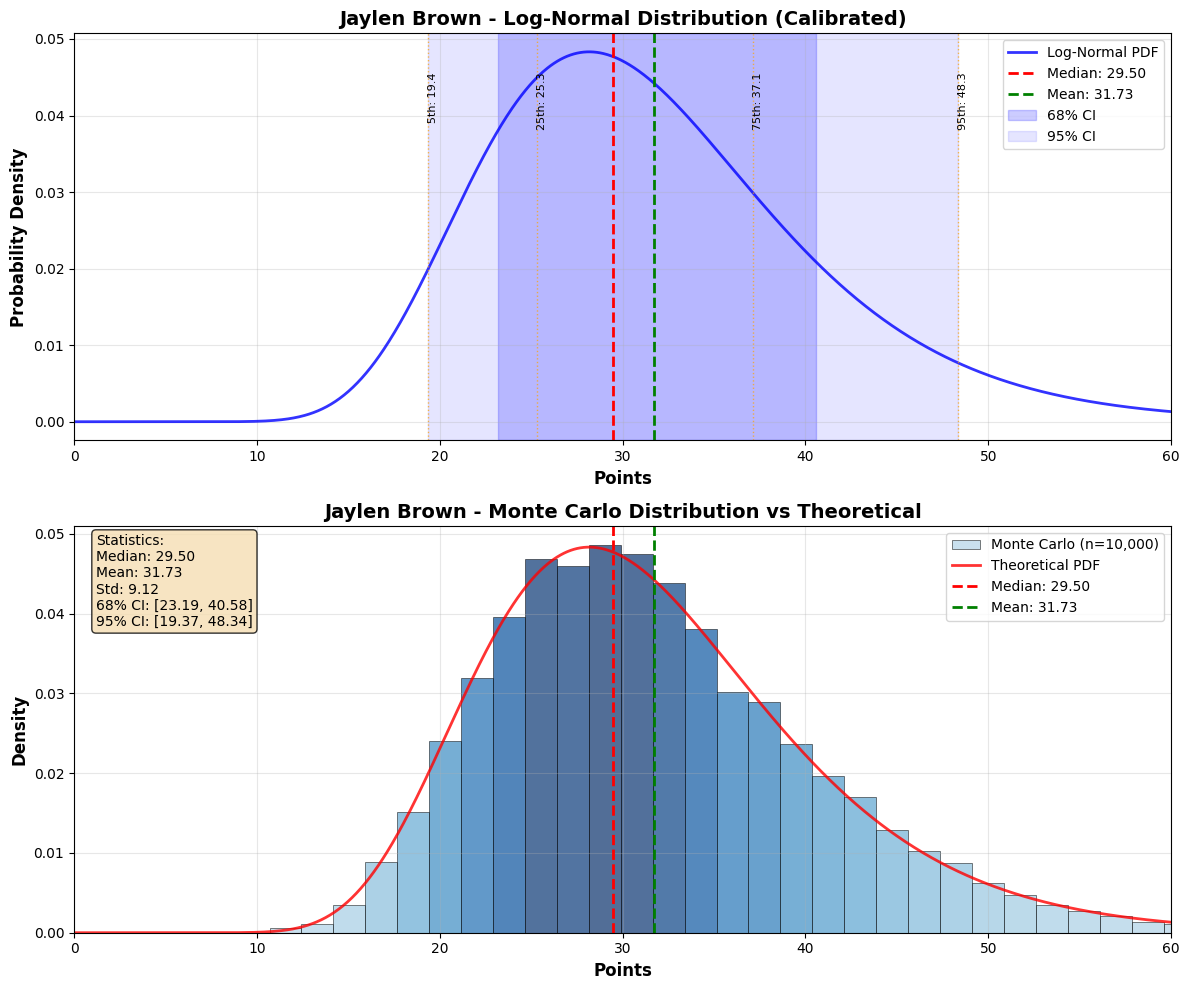

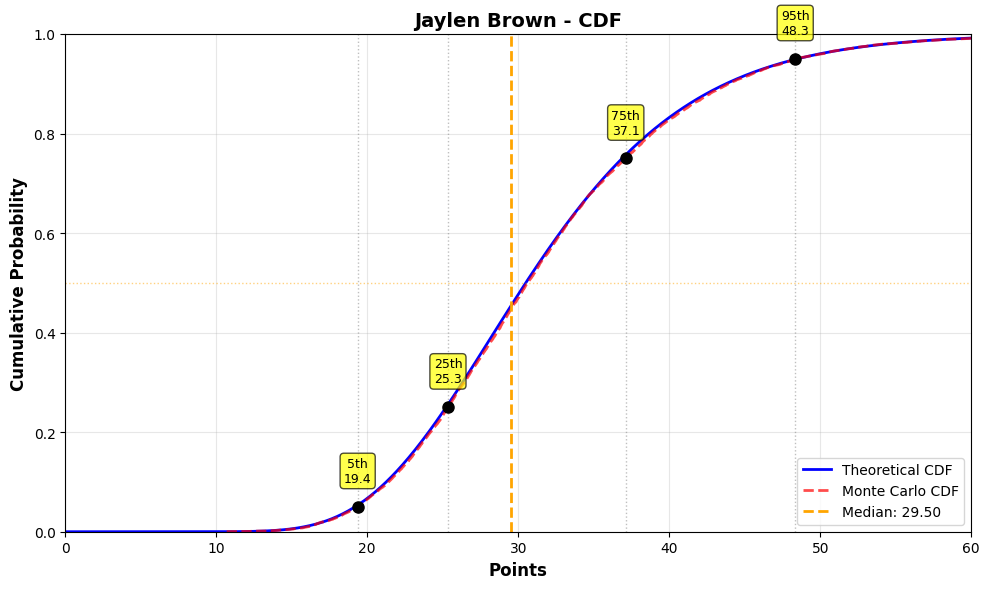

In [6]:
# Create figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ===== TOP PLOT: Theoretical PDF with Statistics =====
ax1 = axes[0]
x = np.linspace(0, max(60, np.percentile(samples, 99)), 1000)
pdf_values = distribution.pdf(x)

# Plot PDF
ax1.plot(x, pdf_values, 'b-', linewidth=2, label='Log-Normal PDF', alpha=0.8)

# Add vertical lines for key statistics
ax1.axvline(median_pred, color='r', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax1.axvline(distribution.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Add confidence intervals
ci_68_low = np.percentile(samples, 16)
ci_68_high = np.percentile(samples, 84)
ci_95_low = np.percentile(samples, 5)
ci_95_high = np.percentile(samples, 95)

ax1.axvspan(ci_68_low, ci_68_high, alpha=0.2, color='blue', label='68% CI')
ax1.axvspan(ci_95_low, ci_95_high, alpha=0.1, color='blue', label='95% CI')

# Add percentiles
percentiles = [5, 25, 75, 95]
percentile_values = [np.percentile(samples, p) for p in percentiles]
percentile_labels = [f'{p}th: {v:.1f}' for p, v in zip(percentiles, percentile_values)]

for p_val, p_label in zip(percentile_values, percentile_labels):
    ax1.axvline(p_val, color='orange', linestyle=':', linewidth=1, alpha=0.7)
    ax1.text(p_val, ax1.get_ylim()[1] * 0.9, p_label, rotation=90, 
             verticalalignment='top', fontsize=8)

ax1.set_xlabel('Points', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title(f'{name} - Log-Normal Distribution (Calibrated)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(60, np.percentile(samples, 99)))

# ===== BOTTOM PLOT: Monte Carlo Histogram =====
ax2 = axes[1]

# Create histogram from Monte Carlo samples
n_bins = 50
counts, bins, patches = ax2.hist(samples, bins=n_bins, density=True, alpha=0.7, 
                                  color='steelblue', edgecolor='black', linewidth=0.5,
                                  label=f'Monte Carlo (n={len(samples):,})')

# Overlay theoretical PDF
ax2.plot(x, pdf_values, 'r-', linewidth=2, label='Theoretical PDF', alpha=0.8)

# Add vertical lines for key statistics
ax2.axvline(median_pred, color='red', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax2.axvline(distribution.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {distribution.mean():.2f}')

# Color bars by density (darker = more frequent)
max_count = max(counts)
for count, patch in zip(counts, patches):
    patch.set_facecolor(plt.cm.Blues(0.3 + 0.7 * count / max_count))

# Add text box with statistics
stats_text = f'''Statistics:
Median: {median_pred:.2f}
Mean: {distribution.mean():.2f}
Std: {distribution.std():.2f}
68% CI: [{ci_68_low:.2f}, {ci_68_high:.2f}]
95% CI: [{ci_95_low:.2f}, {ci_95_high:.2f}]'''

ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_xlabel('Points', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title(f'{name} - Monte Carlo Distribution vs Theoretical', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(60, np.percentile(samples, 99)))

plt.tight_layout()
plt.show()

# ===== Additional: CDF Plot =====
fig2, ax3 = plt.subplots(1, 1, figsize=(10, 6))

# Plot CDF
cdf_values = distribution.cdf(x)
ax3.plot(x, cdf_values, 'b-', linewidth=2, label='Theoretical CDF')

# Monte Carlo CDF (empirical)
sorted_samples = np.sort(samples)
mc_cdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
ax3.plot(sorted_samples, mc_cdf, 'r--', linewidth=2, alpha=0.7, label='Monte Carlo CDF')

# Add median line
ax3.axvline(median_pred, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_pred:.2f}')
ax3.axhline(0.5, color='orange', linestyle=':', linewidth=1, alpha=0.5)

# Add percentile markers
for p, p_val in zip([5, 25, 75, 95], percentile_values):
    ax3.axvline(p_val, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax3.plot(p_val, p/100, 'ko', markersize=8)
    ax3.text(p_val, p/100 + 0.05, f'{p}th\n{p_val:.1f}', 
             ha='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Points', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax3.set_title(f'{name} - CDF', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(60, np.percentile(samples, 99)))
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [7]:
# Calculate probabilities using calibrated distribution
line = betting_line
prob_over = 1 - distribution.cdf(line)
prob_under = distribution.cdf(line)

if odds > 0:
    dec_odds = 1 + (odds / 100.0)
else:
    dec_odds = 1 + (100.0 / abs(odds))

# Calculate Expected Value using actual odds
ev_over = (prob_over * (dec_odds - 1)) - (1 - prob_over)
ev_under = (prob_under * (dec_odds - 1)) - (1 - prob_under)

# Determine recommendation
best_ev = max(ev_over, ev_under)
best_side = "OVER" if ev_over > ev_under else "UNDER"

print(f"\n{'='*60}")
print(f"BETTING ANALYSIS - Line: {line:.1f} | Odds: {odds:+d}")
print(f"{'='*60}")
print(f"Prediction: {median_pred:.2f} points")
print(f"Over {line:.1f}:  {prob_over:.1%} | EV: {ev_over:+.3f}")
print(f"Under {line:.1f}: {prob_under:.1%} | EV: {ev_under:+.3f}")
print(f"\n→ Recommendation: {best_side} {line:.1f} (EV: {best_ev:+.3f})")


BETTING ANALYSIS - Line: 29.5 | Odds: -137
Prediction: 29.50 points
Over 29.5:  54.7% | EV: -0.054
Under 29.5: 45.3% | EV: -0.216

→ Recommendation: OVER 29.5 (EV: -0.054)


In [8]:
# Filter for Underdog player points
# dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'Underdog') & (dfsData['CATEGORY'] == 'player_points')]
dfsPTS = dfsData[(dfsData['BOOKMAKER'] == 'PrizePicks') & (dfsData['CATEGORY'] == 'player_points')]


really_low_volume_lines = dfsPTS[dfsPTS['LINE'].between(4.5, 8.5)]
print(f"Really low volume lines (4.5-7.5): {len(really_low_volume_lines)} bets")

low_volume_lines = dfsPTS[dfsPTS['LINE'].between(8.5, 15.5)]
print(f"Low volume lines (8.5-15.5): {len(low_volume_lines)} bets")

mid_tier_lines = dfsPTS[dfsPTS['LINE'].between(15.5, 22.5)]
print(f"Mid-tier lines (15.5-22.5): {len(mid_tier_lines)} bets")

high_volume_lines = dfsPTS[dfsPTS['LINE'].between(22.5, 35.5)]
print(f"High volume lines (22.5-35.5): {len(high_volume_lines)} bets")

Really low volume lines (4.5-7.5): 62 bets
Low volume lines (8.5-15.5): 102 bets
Mid-tier lines (15.5-22.5): 80 bets
High volume lines (22.5-35.5): 38 bets


In [9]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=really_low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 31 players...
Found 31 valid players
Generated 413 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
66,Josh Minott,Nique Clifford,5.5,8.5,over,under,9.19,2.67,0.816,0.829,0.55,0.54,0.677,0.297,0.380,3.69,5.83,-129,-123,222,3.22,1.1790,117.90,0.1328
166,Steven Adams,Moses Moody,5.5,8.5,over,over,7.70,11.95,0.753,0.781,0.52,0.53,0.588,0.276,0.312,2.20,3.45,-113,-118,248,3.48,1.0446,104.46,0.1053
386,Lonzo Ball,De'Anthony Melton,6.5,8.5,over,over,9.53,11.79,0.744,0.787,0.53,0.56,0.586,0.297,0.289,3.03,3.29,-118,-137,220,3.20,0.8747,87.47,0.0994
277,Jonas Valančiūnas,Dean Wade,8.5,5.5,over,over,10.90,7.38,0.703,0.697,0.51,0.54,0.490,0.275,0.215,2.40,1.88,-110,-122,247,3.47,0.7005,70.05,0.0709
48,Sam Hauser,Buddy Hield,7.5,8.5,over,under,9.40,4.50,0.661,0.692,0.51,0.54,0.457,0.275,0.182,1.90,4.00,-110,-122,247,3.47,0.5871,58.71,0.0594
212,Kobe Sanders,Quinten Post,4.5,7.5,over,under,6.99,4.86,0.726,0.599,0.56,0.49,0.434,0.274,0.160,2.49,2.64,-137,-102,243,3.43,0.4898,48.98,0.0504
0,Jordan Walsh,Aaron Holiday,7.5,8.5,under,over,5.02,9.71,0.581,0.624,0.52,0.51,0.362,0.265,0.097,2.48,1.21,-115,-110,257,3.57,0.2935,29.35,0.0286
383,Isaac Okoro,Luguentz Dort,7.5,7.5,over,over,7.92,7.83,0.568,0.574,0.51,0.52,0.326,0.265,0.061,0.42,0.33,-110,-113,260,3.60,0.1744,17.44,0.0168
231,Jose Alvarado,Rudy Gobert,8.0,8.5,over,over,8.58,8.81,0.594,0.571,0.56,0.53,0.339,0.297,0.042,0.58,0.31,-137,-120,217,3.17,0.0740,7.40,0.0085
125,Kris Dunn,Will Richard,6.5,6.5,over,under,6.64,4.90,0.549,0.508,0.53,0.49,0.279,0.260,0.019,0.14,1.60,-120,-102,263,3.63,0.0122,1.22,0.0012


In [10]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=low_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 51 players...
[MIN] No data found for A.J. Green
[MIN] No data found for Herb Jones
[MIN] No data found for Wendell Carter Jr
Found 48 valid players
Generated 1010 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
523,Jordan Poole,Justin Champagnie,12.5,9.5,over,under,20.83,1.64,0.926,0.954,0.52,0.53,0.883,0.276,0.608,8.33,7.86,-115,-118,245,3.45,2.0479,204.79,0.2090
370,Reed Sheppard,Maxime Raynaud,10.5,11.5,over,under,16.25,5.31,0.860,0.830,0.52,0.49,0.714,0.255,0.459,5.75,6.19,-115,-101,272,3.72,1.6548,165.48,0.1521
141,Anfernee Simons,Nique Clifford,11.5,8.5,over,under,16.62,2.67,0.829,0.829,0.53,0.54,0.687,0.286,0.401,5.12,5.83,-118,-123,235,3.35,1.3009,130.09,0.1384
324,Jabari Smith Jr.,Devin Vassell,14.0,11.5,over,over,20.02,16.36,0.854,0.810,0.56,0.55,0.692,0.308,0.384,6.02,4.86,-137,-127,209,3.09,1.1383,113.83,0.1362
758,Tobias Harris,Moses Moody,13.5,8.5,over,over,16.88,11.95,0.726,0.781,0.51,0.53,0.567,0.270,0.297,3.38,3.45,-108,-118,256,3.56,1.0179,101.79,0.0994
837,Zaccharie Risacher,De'Anthony Melton,10.5,8.5,over,over,12.56,11.79,0.684,0.787,0.49,0.56,0.538,0.274,0.264,2.06,3.29,100,-137,246,3.46,0.8622,86.22,0.0876
720,Jonas Valančiūnas,Harrison Barnes,8.5,10.5,over,over,10.90,12.99,0.703,0.707,0.51,0.51,0.497,0.260,0.237,2.40,2.49,-110,-108,268,3.68,0.8286,82.86,0.0773
274,Ivica Zubac,Jaden McDaniels,14.5,13.5,over,over,16.83,15.08,0.695,0.641,0.52,0.49,0.445,0.255,0.191,2.33,1.58,-115,100,274,3.74,0.6658,66.58,0.0607
973,Buddy Hield,Josh Hart,8.5,13.5,under,under,4.50,8.99,0.692,0.700,0.54,0.55,0.484,0.297,0.187,4.00,4.51,-122,-127,225,3.25,0.5734,57.34,0.0637
6,Kyle Kuzma,Toumani Camara,13.5,13.5,over,over,15.06,15.27,0.636,0.625,0.50,0.50,0.398,0.250,0.148,1.56,1.77,-105,-105,281,3.81,0.5153,51.53,0.0458


In [11]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=mid_tier_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 40 players...
Found 40 valid players
Generated 718 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
240,Amen Thompson,Shaedon Sharpe,16.5,22.5,over,over,22.75,28.95,0.866,0.828,0.51,0.53,0.717,0.270,0.447,6.25,6.45,-111,-121,247,3.47,1.4892,148.92,0.1507
447,Russell Westbrook,Paolo Banchero,17.5,21.5,under,under,10.85,15.31,0.792,0.773,0.52,0.51,0.612,0.265,0.346,6.65,6.19,-115,-110,257,3.57,1.1834,118.34,0.1151
109,Payton Pritchard,Kawhi Leonard,16.5,22.5,over,over,20.87,27.68,0.763,0.809,0.51,0.54,0.617,0.275,0.342,4.37,5.18,-110,-122,247,3.47,1.1409,114.09,0.1155
221,Alperen Sengun,Brandon Miller,20.5,21.5,over,under,25.59,14.74,0.804,0.786,0.57,0.53,0.631,0.302,0.329,5.09,6.76,-141,-118,216,3.16,0.9954,99.54,0.1152
67,Derrick White,Jalen Suggs,18.5,17.5,over,under,23.09,12.40,0.719,0.696,0.52,0.51,0.501,0.265,0.236,4.59,5.10,-113,-110,260,3.60,0.8035,80.35,0.0773
396,Derik Queen,Bennedict Mathurin,16.0,21.5,under,under,11.18,16.68,0.755,0.674,0.56,0.50,0.509,0.280,0.229,4.82,4.82,-137,-106,236,3.36,0.7094,70.94,0.0751
371,Saddiq Bey,Jimmy Butler III,16.5,18.5,under,under,12.11,14.28,0.688,0.678,0.52,0.53,0.467,0.276,0.191,4.39,4.22,-113,-118,248,3.48,0.6236,62.36,0.0629
506,Jalen Duren,CJ McCollum,18.5,20.5,under,under,14.65,16.41,0.653,0.643,0.51,0.51,0.420,0.260,0.160,3.85,4.09,-110,-108,268,3.68,0.5446,54.46,0.0508
427,DeMar DeRozan,De'Aaron Fox,22.0,20.5,under,over,16.96,22.51,0.700,0.650,0.56,0.52,0.455,0.291,0.163,5.04,2.01,-137,-112,227,3.27,0.4863,48.63,0.0536
555,Coby White,Chet Holmgren,22.5,16.5,under,under,18.16,13.36,0.659,0.629,0.54,0.52,0.414,0.281,0.134,4.34,3.14,-122,-112,244,3.44,0.4253,42.53,0.0436


In [12]:
underdogPairs = calculate2LegBets(
    data=s26,
    bookmakers=high_volume_lines,
    engine=engine,
    current_date=current_date,
    top_n=10,                    # Get top 10 bets
    max_player_appearances=1,    # Each player appears max once
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)
underdogPairs

Computing predictions for 19 players...
Found 19 valid players
Generated 162 valid 2-leg combinations


,NAME 1,NAME 2,LINE 1,LINE 2,SIDE 1,SIDE 2,PREDICTION 1,PREDICTION 2,MODEL_PROB 1,MODEL_PROB 2,IMPLIED_PROB 1,IMPLIED_PROB 2,PARLAY_PROB,PARLAY_IMPLIED_PROB,PARLAY_EDGE,EDGE 1,EDGE 2,ODDS 1,ODDS 2,PARLAY_ODDS,PARLAY_DECIMAL,EV,EV_PERCENT,KELLY_QUARTER
77,Shaedon Sharpe,Jamal Murray,22.5,24.5,over,over,28.95,29.23,0.828,0.754,0.53,0.50,0.625,0.265,0.360,6.45,4.73,-121,-105,257,3.57,1.2306,123.06,0.1197
60,Kawhi Leonard,Stephen Curry,22.5,24.5,over,over,27.68,29.99,0.809,0.749,0.54,0.50,0.606,0.270,0.336,5.18,5.49,-122,-106,254,3.54,1.1451,114.51,0.1127
11,Jaylen Brown,Donovan Mitchell,29.5,30.5,over,over,34.59,35.14,0.716,0.718,0.49,0.50,0.514,0.245,0.269,5.09,4.64,100,-104,292,3.92,1.0152,101.52,0.0869
23,Kevin Durant,Jalen Johnson,25.5,23.5,over,under,27.76,19.46,0.656,0.629,0.49,0.49,0.413,0.240,0.173,2.26,4.04,100,-102,296,3.96,0.6345,63.45,0.0536
130,Coby White,Tyrese Maxey,22.5,28.5,under,over,18.16,30.39,0.659,0.620,0.54,0.49,0.408,0.265,0.144,4.34,1.89,-122,-102,260,3.60,0.4706,47.06,0.0452
75,Deni Avdija,Shai Gilgeous-Alexander,26.5,30.5,under,under,23.47,27.30,0.579,0.585,0.51,0.50,0.339,0.255,0.084,3.03,3.20,-110,-105,273,3.73,0.2651,26.51,0.0243
37,James Harden,Cade Cunningham,22.5,26.5,over,over,22.87,27.44,0.557,0.572,0.51,0.52,0.319,0.265,0.054,0.37,0.94,-110,-113,260,3.60,0.1475,14.75,0.0142
98,Nikola Jokić,Jalen Brunson,29.5,28.5,over,over,29.88,28.67,0.547,0.533,0.51,0.49,0.291,0.250,0.041,0.38,0.17,-110,-102,278,3.78,0.1013,10.13,0.0091
138,Miles Bridges,Pascal Siakam,22.5,24.5,under,under,20.33,22.66,0.541,0.521,0.52,0.54,0.282,0.281,0.001,2.17,1.84,-114,-123,240,3.40,-0.0410,-4.10,0.0000


## For low line players

In [15]:
players = really_low_volume_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_usage': result['predicted_usage'],
        'predicted_fga': result['predicted_fga'],
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

[MIN] No data found for Jonas Valanciunas
[MIN] No data found for Vit Krejci
[MIN] No data found for Isaiah Stewart II


,player,predicted_minutes,predicted_usage,predicted_fga,predicted_points
0,Jordan Walsh,28.26,0.118514,6.392710,5.02
1,Sam Hauser,22.30,0.131577,8.835017,9.40
2,Josh Minott,15.03,0.130808,5.949192,9.19
3,Aaron Holiday,15.25,0.165781,5.578795,9.71
4,Kris Dunn,26.35,0.127969,5.451125,6.64
5,Josh Okogie,24.84,0.128770,6.939828,5.41
6,Steven Adams,15.06,0.128445,3.961523,7.70
7,Nicolas Batum,14.87,0.115794,3.615855,3.97
8,Kobe Sanders,13.08,0.148537,4.377349,6.99
9,Jose Alvarado,21.81,0.152314,6.558834,8.58


## For mid line players

In [17]:
players = mid_tier_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_usage': round(result['predicted_usage'],3),
        'predicted_fga': round(result['predicted_fga'],2),
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

[MIN] No data found for Nikola Vucevic
[MIN] No data found for C.J. McCollum
[MIN] No data found for Jimmy Butler


,player,predicted_minutes,predicted_usage,predicted_fga,predicted_points
0,Kevin Porter Jr.,23.59,0.223,7.41,18.05
1,Derrick White,27.49,0.233,10.51,23.09
2,Ryan Rollins,34.00,0.222,13.10,16.17
3,Payton Pritchard,29.72,0.191,11.60,20.87
4,James Harden,34.24,0.276,16.45,22.87
5,Kawhi Leonard,23.63,0.252,10.29,27.68
6,Alperen Sengun,29.12,0.267,13.38,25.59
7,Amen Thompson,28.03,0.198,11.56,22.75
8,Shaedon Sharpe,24.92,0.253,15.97,28.95
9,Trey Murphy III,30.64,0.204,12.17,20.52


## High Value Lines

In [19]:
players = high_volume_lines['NAME'].unique()
results = []
for player in players:
    result = engine.project_player(
        player_name=player,  # Changed from 'name' to 'player'
        data=s26,
        date=current_date,  # Uses the date set in Cell 1
        projectedStartingFive=projectedStartingFive,
        mainStartingFive=mainStartingFive,
        teamStarPlayer=teamStarPlayer,
        league_df=league_df,
        findOpp=findOpp
    )
    if result is None:
        # Skip players where prediction failed
        continue
    results.append({
        'player': player,
        'predicted_minutes': round(result['predicted_minutes'],2),
        'predicted_usage': round(result['predicted_usage'],3),
        'predicted_fga': round(result['predicted_fga'],2),
        'predicted_points': round(result['predicted_points'],2),
    })
results = pd.DataFrame(results)
results

[MIN] No data found for Nikola Jokic


,player,predicted_minutes,predicted_usage,predicted_fga,predicted_points
0,Jaylen Brown,28.40,0.313,12.95,34.59
1,Kevin Durant,29.85,0.252,12.97,27.76
2,James Harden,34.24,0.276,16.45,22.87
3,Kawhi Leonard,23.63,0.252,10.29,27.68
4,Deni Avdija,31.31,0.269,16.68,23.47
5,Shaedon Sharpe,24.92,0.253,15.97,28.95
6,Jamal Murray,30.13,0.237,13.29,29.23
7,Cade Cunningham,32.27,0.296,15.71,27.44
8,Jalen Johnson,33.15,0.238,12.01,19.46
9,Coby White,30.70,0.287,17.70,18.16
